In [1]:
# %pip install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/round4/prices_round_4_day_1.csv", delimiter=";")

# tickers = ["EMERALDS", "TOMATOES"] # Tutorial round 
#tickers = ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"] # Round 1
tickers = ["VELVETFRUIT_EXTRACT", "HYDROGEL_PACK"] # Round 4

df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,1,0,VELVETFRUIT_EXTRACT,5242,54,NaN,NaN,NaN,NaN,5248,54,NaN,NaN,NaN,NaN,5245.0,0.0
1,1,0,HYDROGEL_PACK,9950,13,9947.0,23.0,NaN,NaN,9966,13,9968.0,23.0,NaN,NaN,9958.0,0.0
2,1,0,VEV_6000,0,22,NaN,NaN,NaN,NaN,1,22,NaN,NaN,NaN,NaN,0.5,0.0
3,1,0,VEV_5000,248,19,NaN,NaN,NaN,NaN,254,6,255.0,13.0,NaN,NaN,251.0,0.0
4,1,0,VEV_6500,0,18,NaN,NaN,NaN,NaN,1,18,NaN,NaN,NaN,NaN,0.5,0.0


In [2]:
prices = df.pivot(index="timestamp", columns="product", values="mid_price")

for ticker in tickers:
    clean = prices[ticker][prices[ticker] > 0].dropna()

    print("=" * 5 + ticker + "=" * 5)
    print(clean.describe())
    print()

=====VELVETFRUIT_EXTRACT=====
count    10000.000000
mean      5248.391900
std         14.614362
min       5198.000000
25%       5238.500000
50%       5248.500000
75%       5259.000000
max       5283.000000
Name: VELVETFRUIT_EXTRACT, dtype: float64

=====HYDROGEL_PACK=====
count    10000.000000
mean      9992.055100
std         37.613011
min       9908.500000
25%       9958.000000
50%       9999.000000
75%      10017.000000
max      10079.000000
Name: HYDROGEL_PACK, dtype: float64



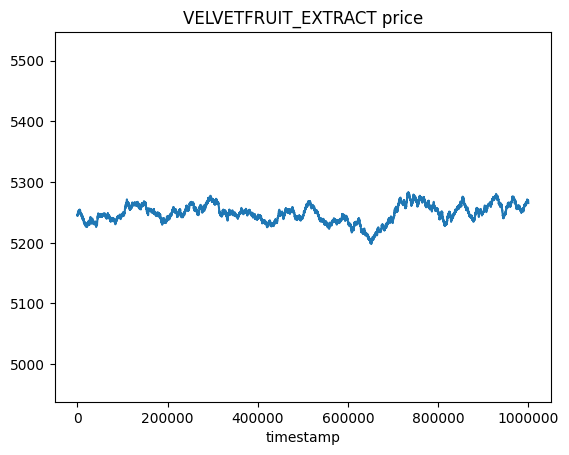

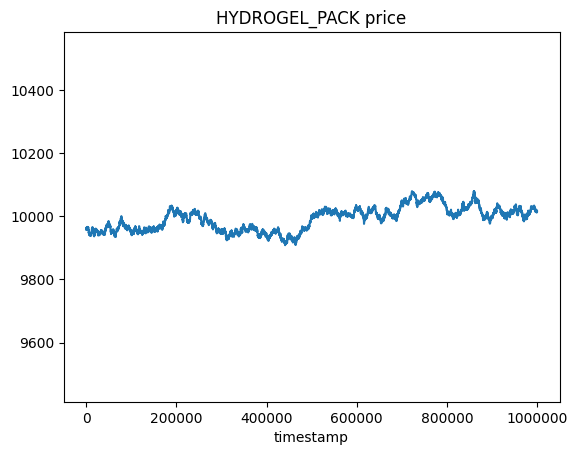

In [3]:

for ticker in tickers:
    # Filter out rows where mid_price is 0 or NaN
    clean = prices[ticker]
    clean = clean[clean > 0]      # removes zeros
    clean = clean.dropna()        # removes NaN (probably already gone but just in case)

    ax = clean.plot(
        title=f"{ticker} price",
        ylim=(clean.min() * 0.95, clean.max() * 1.05),
    )
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.show()

In [4]:
import numpy as np

ticker = "INTARIAN_PEPPER_ROOT"
clean = prices[ticker][prices[ticker] > 0].dropna()

# Fit a linear regression line to find the overall trend
x = clean.index.values
y = clean.values

slope, intercept = np.polyfit(x, y, 1)

# Plot the actual price and the trendline
plt.figure()
ax = clean.plot(label=ticker, alpha=0.7)
trendline = slope * x + intercept
plt.plot(x, trendline, color='red', label=f'Trendline (slope: {slope:.5f})')
plt.title(f"{ticker} Price Trend")
ax.ticklabel_format(axis="x", style="plain", useOffset=False)
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
plt.legend()
plt.show()

print(f"The overall trend step per timestamp tick is: {slope:.5f}")
print(f"The intercept of the trendline is: {intercept:.2f}")

KeyError: 'INTARIAN_PEPPER_ROOT'